# Occlusion Detection Demo

This notebook demonstrates how to use the `occlusion_detection` package to detect and localize occlusions in images using anomaly detection techniques.

The detection pipeline uses:
1. A feature extractor (e.g., DINOv2) to extract patch-level features
2. A memory bank of reference features from clean images
3. Anomaly scoring based on feature similarity

In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# Import from the occlusion_detection package
from occlusion_detection import (
    # Transforms
    LocalizeOcclusion,
    LocalizeAndMaskOcclusion,
    # Functions
    anomaly_map_to_occ_map,
    batched_anomaly_map_to_occ_map,
)

# Import from occlusion_generation for creating test samples
from occlusion_generation import (
    ApplyGrayOcclusion, 
    ApplyOverlayOcclusion,
    perlin_mask
)

from utils import unnormalize

## 0. Generate Occluded Samples

Load a real image and apply `ApplyOverlayOcclusion` to produce a set of synthetic occluded samples that will be used throughout this notebook.

Loaded 10 overlay cutouts


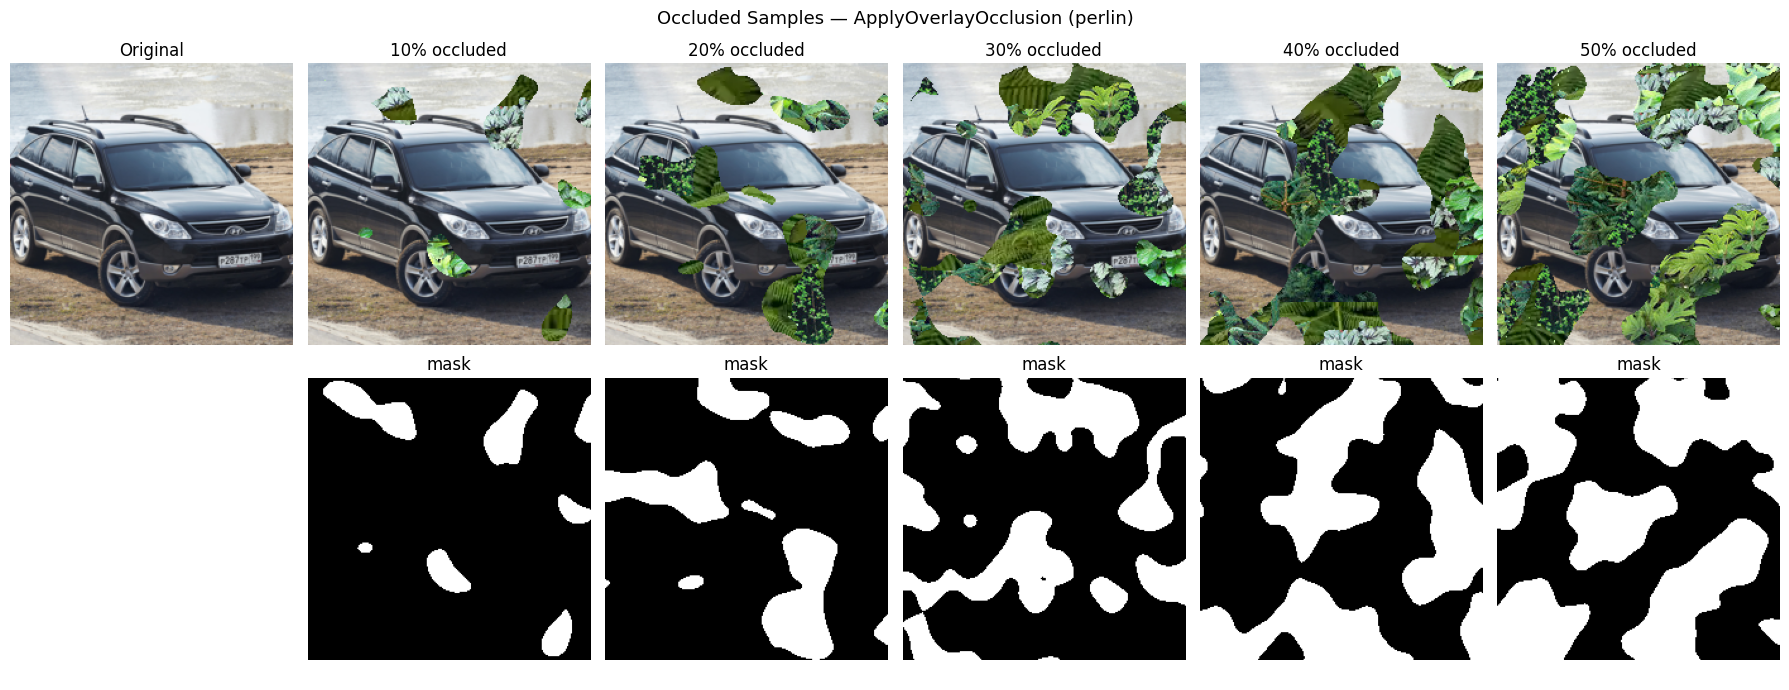

In [ ]:
from torchvision.io import read_image, decode_image, ImageReadMode
from torchvision.transforms import v2
from glob import glob

from occlusion_generation import ApplyOverlayOcclusion

# Load and preprocess source image
source_tensor = read_image("examples/data/samples/010972.jpg", mode=ImageReadMode.RGB)
source_tensor = v2.Compose([v2.Resize(256, antialias=True), v2.CenterCrop(224)])(source_tensor)

# Load RGBA overlay cutouts
overlay_paths = glob("examples/data/overlays/*.png")
overlay_tensors = [decode_image(p, mode=ImageReadMode.RGB_ALPHA) for p in overlay_paths]
print(f"Loaded {len(overlay_tensors)} overlay cutouts")

# Generate occluded samples at different occlusion levels
occlusion_percents = [10, 20, 30, 40, 50]
overlay_transform = ApplyOverlayOcclusion(
    overlays=overlay_tensors,
    occlusion_type="perlin",
    return_mask=True,
)

occluded_samples = []
for pct in occlusion_percents:
    overlay_transform.occlusion_percent = pct
    
    compose_transform = v2.Compose([
        v2.Resize(224, antialias=True),
        overlay_transform,
        v2.ToDtype(torch.float32, scale=True),
        v2.CenterCrop(224)
    ])

    occluded, mask = compose_transform(source_tensor)
    occluded_samples.append((occluded, mask, pct))

# Visualise
fig, axes = plt.subplots(2, len(occluded_samples) + 1, figsize=(18, 7))

axes[0, 0].imshow(source_tensor.permute(1, 2, 0))
axes[0, 0].set_title("Original")
axes[0, 0].axis("off")
axes[1, 0].axis("off")

for col, (occluded, mask, pct) in enumerate(occluded_samples, start=1):
    actual_pct = mask.sum() / mask.numel() * 100
    axes[0, col].imshow(occluded.permute(1, 2, 0))
    axes[0, col].set_title(f"{pct}% occluded")
    axes[0, col].axis("off")

    axes[1, col].imshow(mask, cmap="gray")
    axes[1, col].set_title("mask")
    axes[1, col].axis("off")

plt.suptitle("Occluded Samples — ApplyOverlayOcclusion (perlin)", fontsize=13)
plt.tight_layout()
plt.show()

# Expose for use in later cells
occluded_image, gt_mask = occluded_samples[2][0], occluded_samples[2][1]  # 30% sample used below

## 1. Setup Anomaly Detection Pipeline
Initialize the feature extractor and memory bank, and compute anomaly scores for the occluded samples.

In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# --- DINOv2 backbone (ViT-B/14, 768-dim) ---
feature_extractor = torch.hub.load("facebookresearch/dinov2", "dinov2_vitb14")
feature_extractor.eval().to(device)

# --- DINOv2 preprocessing transforms ---
# ViT-B/14: expects 224×224 float tensors normalised with ImageNet stats
dinov2_transforms = v2.Compose([
    v2.Resize(224, antialias=True),
    v2.CenterCrop(224),
    v2.ToDtype(torch.float32, scale=True),          # uint8 → [0, 1]
    v2.Normalize(mean=[0.485, 0.456, 0.406],
                 std =[0.229, 0.224, 0.225]),
])


Using device: cpu


Using cache found in /Users/kaygijzen/.cache/torch/hub/facebookresearch_dinov2_main


Found 5 reference images
Extracted 1280 patch embeddings from 5 images (dim=768)
Memory bank ready: 1280 patches  (dim=768)


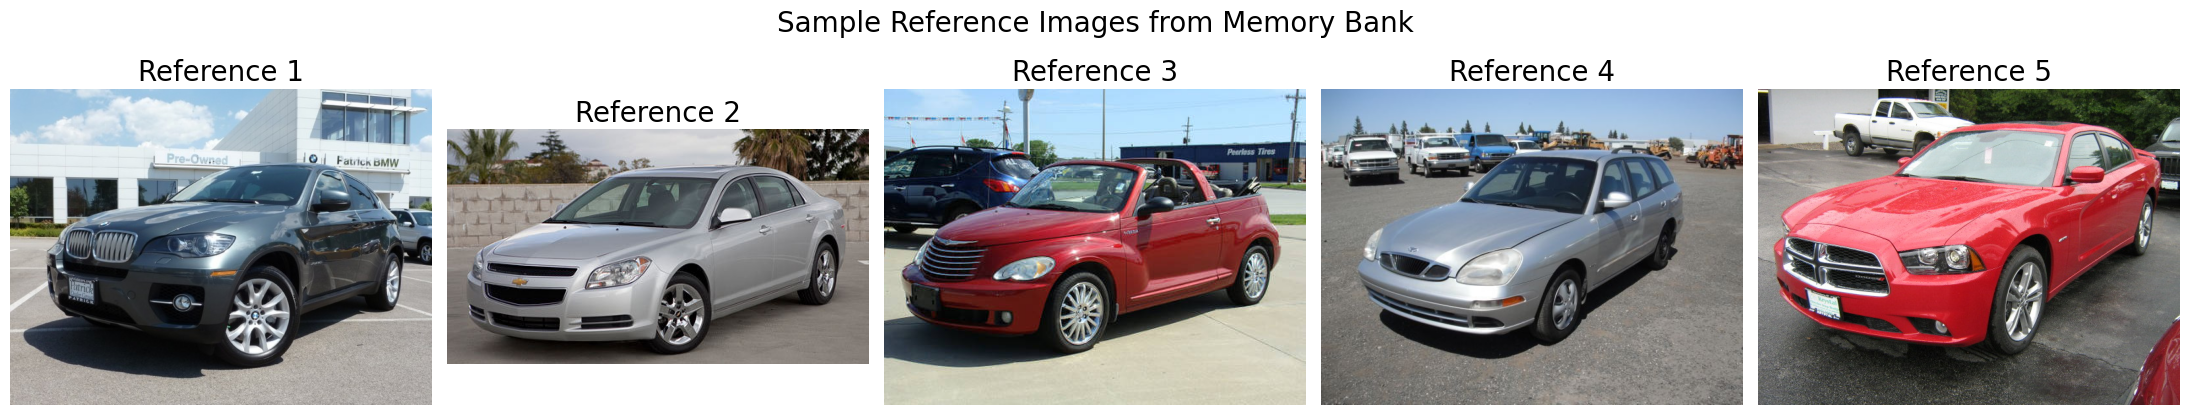

In [43]:
# --- Build memory bank from real reference images ---
ref_image_paths = sorted(
    glob("examples/data/reference_images/global_top_k/*.jpg") +
    glob("examples/data/reference_images/global_top_k/*.png")
)
print(f"Found {len(ref_image_paths)} reference images")

if not ref_image_paths:
    raise RuntimeError(
        "No images found in examples/data/reference_images/global_top_k/. "
        "Add clean (occlusion-free) reference images to build the memory bank."
    )

all_features = []
with torch.inference_mode():
    for path in ref_image_paths:
        img = read_image(path, mode=ImageReadMode.RGB)
        img_tensor = dinov2_transforms(img).unsqueeze(0).to(device)  # (1, 3, H, W)
        tokens = feature_extractor.get_intermediate_layers(img_tensor)[0]  # (1, N_patches, D)
        all_features.append(tokens.squeeze(0).cpu().numpy())             # (N_patches, D)

reference_features = np.concatenate(all_features, axis=0)  # (N_total_patches, D)

# L2-normalise before fitting — required for cosine similarity
reference_features = reference_features / np.linalg.norm(reference_features, axis=1, keepdims=True)

print(f"Extracted {reference_features.shape[0]} patch embeddings "
      f"from {len(ref_image_paths)} images (dim={reference_features.shape[1]})")

memory_bank = NearestNeighbors(n_neighbors=1, metric="cosine").fit(reference_features)
print(f"Memory bank ready: {reference_features.shape[0]} patches  (dim={reference_features.shape[1]})")

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))
for i, path in enumerate(ref_image_paths[:5]):
    img = read_image(path, mode=ImageReadMode.RGB)
    axes[i].imshow(img.permute(1, 2, 0))
    axes[i].set_title(f"Reference {i+1}", fontsize=20)
    axes[i].axis("off")
plt.suptitle("Sample Reference Images from Memory Bank", fontsize=20)
plt.tight_layout()


## 2. Localizing and Masking occlusion

In [44]:
from torchvision.io import read_image, decode_image, ImageReadMode
from torchvision.transforms import v2
from glob import glob

from occlusion_generation import ApplyOverlayOcclusion

# Load and preprocess the source image
source_image_path = "examples/data/samples/010972.jpg"
source_tensor = read_image(source_image_path, mode=ImageReadMode.RGB)
source_tensor = v2.Compose([v2.Resize(256, antialias=True), v2.CenterCrop(224)])(source_tensor)

# Load RGBA overlay cutouts
overlay_paths = glob("examples/data/overlays/*.png")
overlay_tensors = [decode_image(p, mode=ImageReadMode.RGB_ALPHA) for p in overlay_paths]
print(f"Loaded {len(overlay_tensors)} overlay cutouts")

# Apply overlay occlusion at 40%
overlay_transform = ApplyOverlayOcclusion(
    overlays=overlay_tensors,
    occlusion_percent=40,
    occlusion_type="perlin",
    return_mask=True,
)
occluded_image, gt_mask = overlay_transform(source_tensor)

actual_pct = gt_mask.sum() / gt_mask.numel() * 100
print(f"Occluded image shape: {occluded_image.shape}, GT mask coverage: {actual_pct:.1f}%")


Loaded 10 overlay cutouts
Occluded image shape: torch.Size([3, 224, 224]), GT mask coverage: 40.0%


In [45]:
# Masking color: neutral gray (0.5, 0.5, 0.5) normalized under DINOv2 ImageNet stats
_mean = torch.tensor([0.485, 0.456, 0.406])
_std  = torch.tensor([0.229, 0.224, 0.225])
gray_normalized = (torch.tensor([0.5, 0.5, 0.5]) - _mean) / _std  # (3,)

# --- LocalizeAndMaskOcclusion transform ---
loma_transform = LocalizeAndMaskOcclusion(
    feature_extractor=feature_extractor,
    memory_bank=memory_bank,
    masking_color=gray_normalized,
    grid_size=(16, 16),   # 224 / 14 = 16 patches per side
    use_otsu=True,
    return_anomaly_map=True,
    device=device,
)
print("LocalizeAndMaskOcclusion ready.")


LocalizeAndMaskOcclusion ready.


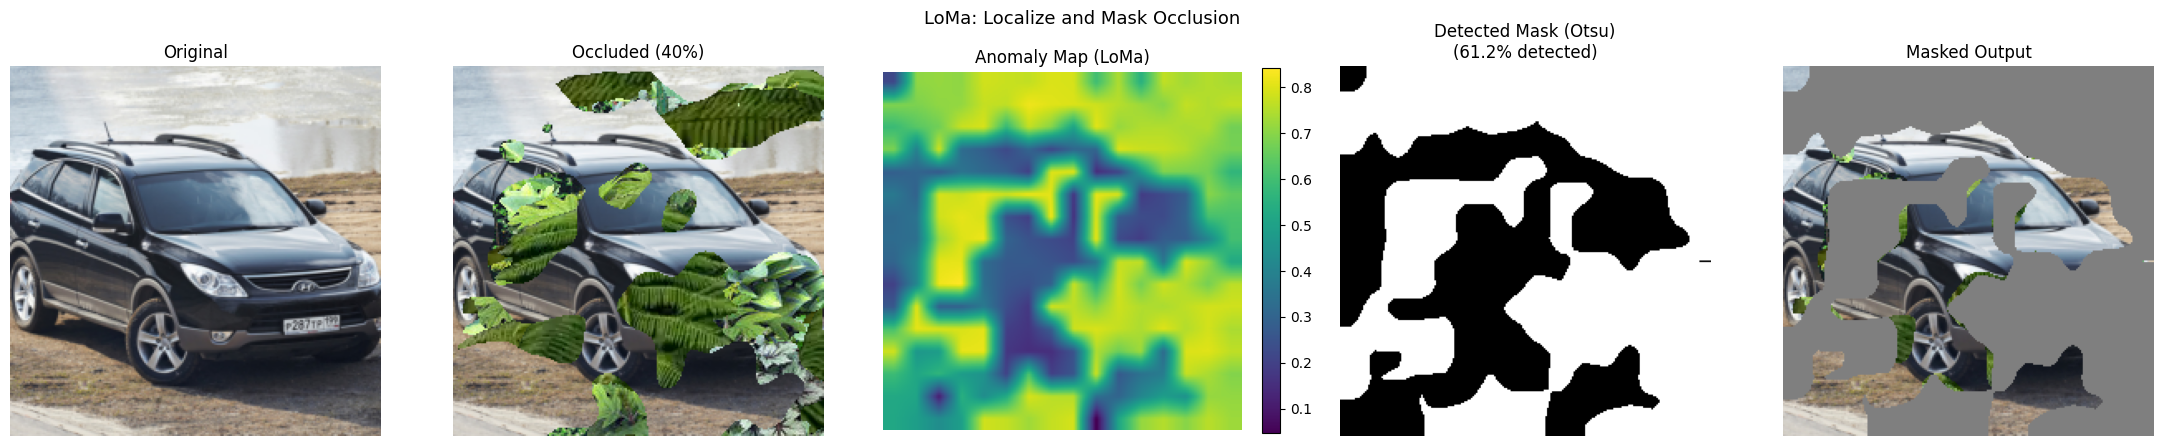

In [46]:
# Preprocess occluded image for DINOv2
occluded_preprocessed = dinov2_transforms(occluded_image).unsqueeze(0).to(device)  # (1, 3, 224, 224)

# Run LoMa: returns (masked_img, occ_map, anomaly_map), all in normalized space
masked_image, occ_map, anomaly_map = loma_transform(occluded_preprocessed)

display_masked = unnormalize(masked_image.squeeze(0).cpu())  # (3, H, W), in [0, 1] for display

# --- Visualize ---
fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

axes[0].imshow(source_tensor.permute(1, 2, 0))
axes[0].set_title('Original')
axes[0].axis('off')

axes[1].imshow(occluded_image.permute(1, 2, 0))
axes[1].set_title('Occluded (40%)')
axes[1].axis('off')

im = axes[2].imshow(anomaly_map.squeeze(0).cpu(), cmap='viridis')
axes[2].set_title('Anomaly Map (LoMa)')
axes[2].axis('off')
plt.colorbar(im, ax=axes[2], fraction=0.046)

coverage = occ_map.sum() / occ_map.numel() * 100
axes[3].imshow(occ_map.squeeze(0).cpu(), cmap='gray')
axes[3].set_title(f'Detected Mask (Otsu)\n({coverage:.1f}% detected)')
axes[3].axis('off')

axes[4].imshow(display_masked.permute(1, 2, 0))
axes[4].set_title('Masked Output')
axes[4].axis('off')

plt.suptitle('LoMa: Localize and Mask Occlusion', fontsize=13)
plt.tight_layout()
plt.show()


## 3. Converting Anomaly Maps to Binary Occlusion Maps

Use thresholding or Otsu's method to convert continuous anomaly scores to binary occlusion masks. And masking the occluded image with the detected occlusion mask.

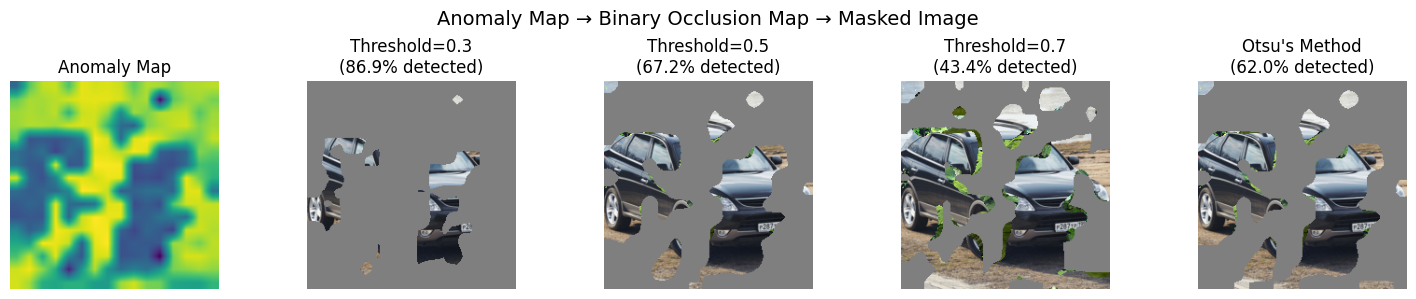

In [34]:
# Convert anomaly map to binary occlusion map with different thresholds
thresholds = [0.3, 0.5, 0.7, "otsu"]

fig, axes = plt.subplots(1, len(thresholds) + 1, figsize=(15, 3))

axes[0].imshow(anomaly_map.squeeze(0), cmap="viridis")
axes[0].set_title("Anomaly Map")
axes[0].axis("off")

for idx, thresh in enumerate(thresholds):
    if thresh == "otsu":
        occ_map = anomaly_map_to_occ_map(anomaly_map.numpy(), use_otsu=True)
        title = "Otsu's Method"
    else:
        occ_map = anomaly_map_to_occ_map(anomaly_map.numpy(), masking_threshold=thresh, use_otsu=False)
        title = f"Threshold={thresh}"

    if type(occ_map) == tuple:
        occ_map, otsu_threshold = occ_map  # If Otsu returns (mask, threshold)


    masked_image = occluded_image.clone()
    masked_image[:, occ_map.squeeze(0) == 1] = 127
    
    # occ_map = torch.from_numpy(occ_map)
    coverage = occ_map.sum() / occ_map.numel() * 100
    
    axes[idx + 1].imshow(masked_image.squeeze(0).permute(1, 2, 0))
    axes[idx + 1].set_title(f"{title}\n({coverage:.1f}% detected)")
    axes[idx + 1].axis("off")

plt.suptitle("Anomaly Map → Binary Occlusion Map → Masked Image", fontsize=14)
plt.tight_layout()
plt.show()

## 4. Evaluation Metrics

The `utils` package provides metrics for evaluating detection performance.

In [49]:
# from utils import compute_batched_precision_recall_f1, compute_batched_auroc

# # Add batch dimension
# gt_batch = gt_mask.unsqueeze(0)
# detected_batch = occ_map.unsqueeze(0).float()
# anomaly_batch = anomaly_map.unsqueeze(0)

# # Compute metrics
# precision, recall, f1 = compute_batched_precision_recall_f1(detected_batch, gt_batch)
# auroc = compute_batched_auroc(anomaly_batch, gt_batch)

# print("Detection Performance:")
# print(f"  Precision: {precision:.3f}")
# print(f"  Recall:    {recall:.3f}")
# print(f"  F1 Score:  {f1:.3f}")
# print(f"  AUROC:     {auroc:.3f}")